# CMB TT Spectrum Calculation (Simplified)

This notebook demonstrates how to compute the CMB temperature power spectrum using DISCO-EB's modular CMB functions.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# Check JAX backend
try:
    backend = jax.extend.backend.get_backend()
    print(f"JAX backend: {backend.platform}")
except AttributeError:
    print(f"JAX backend: {jax.default_backend()}")

print(f"Devices: {jax.devices()}")

JAX backend: cpu
Devices: [CpuDevice(id=0)]


## Import DISCO-EB modules

In [2]:
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations_batched, model_synchronous
from discoeb.cmb import (
    extract_perturbations,
    compute_neutrino_perturbations,
    compute_metric_perturbations,
    compute_source_function,
    compute_theta_ell,
    compute_Cell,
)
from discoeb.spline_interpolation import spline_interpolation

/home/ljb200/git/DISCO-EB/.venv/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Set cosmological parameters

In [3]:
param = {}
param['Omegam']  = 0.3099            # Total matter density
param['Omegab']  = 0.0488911         # Baryon density
param['w_DE_0']  = -0.99             # Dark energy EOS today
param['w_DE_a']  = 0.0               # Dark energy EOS derivative
param['cs2_DE']  = 1.0               # Dark energy sound speed squared
param['Omegak']  = 0.0               # Curvature
param['A_s']     = 2.1064e-09        # Primordial amplitude
param['n_s']     = 0.96822           # Spectral index
param['H0']      = 67.742            # Hubble constant (km/s/Mpc)
param['Tcmb']    = 2.7255            # CMB temperature (K)
param['YHe']     = 0.248             # Helium mass fraction
param['Neff']    = 2.046             # Effective relativistic species
param['Nmnu']    = 1                 # Massive neutrino species
param['mnu']     = 0.06              # Neutrino mass (eV)
param['k_p']     = 0.05              # Pivot scale (1/Mpc)

# Wavenumber sampling
nmodes = 512
kmin   = 1e-4
kmax   = 1.0

## Compute background evolution

In [4]:
print("Computing background evolution...")
param = evolve_background(param=param, thermo_module='RECFAST', num_thermo=1024)
print(f"Background complete. Thermal history has {len(param['aexp'])} points")

Computing background evolution...
Background complete. Thermal history has 1024 points


## Compute perturbation evolution

In [5]:
# Dense sampling near recombination, coarser at late times
aexp_out = jnp.geomspace(3e-4, 5e-3, 256, endpoint=False)
aexp_out = jnp.append(aexp_out, jnp.geomspace(5e-3, 1.0, 64))

print(f"Computing perturbations for {nmodes} k-modes at {len(aexp_out)} output times...")
yout, kmodes, param = evolve_perturbations_batched(
    param=param, 
    kmin=kmin, 
    kmax=kmax, 
    num_k=nmodes, 
    aexp_out=aexp_out,
    rtol=1e-4, 
    atol=1e-4,
    return_full=True,
    dologk=True,
)

print(f"Perturbations computed. Output shape: {yout.shape}")

Computing perturbations for 512 k-modes at 320 output times...
Perturbations computed. Output shape: (512, 320, 72)


## Compute time derivatives

In [6]:
# Extract parameters
tau = param['tau_out']
lmaxg = param['lmaxg']
lmaxgp = param['lmaxgp']
lmaxr = param['lmaxr']
lmaxnu = param['lmaxnu']
nqmax = param['nqmax']

# Compute derivatives by re-evaluating the ODE system
print("Computing time derivatives...")
idxtau = jnp.arange(len(tau))
idxk = jnp.arange(len(kmodes))

yprime = jax.vmap(
    lambda ik: jax.vmap(
        lambda itau: model_synchronous(
            tau=tau[itau], 
            y=yout[ik, itau, :], 
            param=param, 
            kmode=kmodes[ik],
            lmaxg=lmaxg, 
            lmaxgp=lmaxgp, 
            lmaxr=lmaxr, 
            lmaxnu=lmaxnu, 
            nqmax=nqmax
        )
    )(idxtau)
)(idxk)

print(f"Derivatives computed. Shape: {yprime.shape}")

Computing time derivatives...
Derivatives computed. Shape: (512, 320, 72)


## Compute CMB source function

We'll compute the source function in several steps:
1. Extract perturbations from the state vector
2. Compute background quantities and visibility functions
3. Compute neutrino perturbations
4. Compute metric perturbations
5. Compute the four source terms (ISW, Sachs-Wolfe, Doppler, Polarization)

In [7]:
print("Computing CMB source function components...")

# 1. Extract perturbations from state vector
perturbations = extract_perturbations(yout, yprime, lmaxg, lmaxgp, lmaxr)

# 2. Compute background quantities
a = aexp_out
rhonu = jnp.exp(param['logrhonu_of_loga_spline'].evaluate(jnp.log(a)))
rho_Q = a**(-3 * (1 + param['w_DE_0'] + param['w_DE_a'])) * jnp.exp(3 * (a - 1) * param['w_DE_a'])
w_Q = param['w_DE_0'] + param['w_DE_a'] * (1.0 - a)

background_quantities = {
    'rhonu': rhonu,
    'rho_Q': rho_Q,
    'w_Q': w_Q,
}

# 3. Compute visibility functions
tau = param['tau_of_a_spline'].evaluate(a)

opacspline = spline_interpolation(jnp.log(param['tau']), param['opac'])
opac = opacspline.evaluate(jnp.log(tau))
opacprime = opacspline.derivative(jnp.log(tau)) / tau

gvis_spline = spline_interpolation(jnp.log(param['tau']), param['gvis'])
gvisprime_spline = spline_interpolation(jnp.log(param['tau']), param['gvisprime'])
gvispprime_spline = spline_interpolation(jnp.log(param['tau']), param['gvispprime'])

gvis = gvis_spline.evaluate(jnp.log(tau))
gvisprime = gvisprime_spline.evaluate(jnp.log(tau))
gvispprime = gvispprime_spline.evaluate(jnp.log(tau))

optical_depth_spline = spline_interpolation(
    jnp.log(param['tau']),
    jnp.log(jnp.maximum(param['optical_depth'], 1e-10))
)
optical_depth = jnp.exp(optical_depth_spline.evaluate(jnp.log(tau)))

visibility_functions = {
    'opac': opac,
    'opacprime': opacprime,
    'gvis': gvis,
    'gvisprime': gvisprime,
    'gvispprime': gvispprime,
    'optical_depth': optical_depth,
}

print("  - Perturbations extracted")
print("  - Background quantities computed")
print("  - Visibility functions computed")

Computing CMB source function components...
  - Perturbations extracted
  - Background quantities computed
  - Visibility functions computed


In [8]:
# 4. Compute neutrino perturbations
print("Computing neutrino perturbations...")
neutrinos = compute_neutrino_perturbations(
    yout, yprime, aexp_out, param, nqmax, perturbations['iq0']
)
print("  - Neutrino perturbations computed")

Computing neutrino perturbations...
  - Neutrino perturbations computed


In [9]:
# 5. Compute metric perturbations from Einstein equations
print("Computing metric perturbations...")
metric = compute_metric_perturbations(
    perturbations, neutrinos, background_quantities, param, kmodes, aexp_out
)
print("  - Metric perturbations computed")

Computing metric perturbations...
  - Metric perturbations computed


In [10]:
# 6. Compute the four CMB source terms
print("Computing CMB source terms...")
source_results = compute_source_function(
    perturbations, metric, visibility_functions, yout, yprime, kmodes, lmaxg, lmaxgp
)

S = source_results['S']      # Total source function
S1 = source_results['S1']    # ISW (Integrated Sachs-Wolfe)
S2 = source_results['S2']    # Sachs-Wolfe
S3 = source_results['S3']    # Doppler
S4 = source_results['S4']    # Polarization

print(f"\nSource function computed. Shape: {S.shape}")
print("  - S1 (ISW): Time-varying gravitational potentials")
print("  - S2 (Sachs-Wolfe): Temperature + potential at last scattering")
print("  - S3 (Doppler): Bulk motion of baryons")
print("  - S4 (Polarization): E-mode coupling")

Computing CMB source terms...

Source function computed. Shape: (512, 320)
  - S1 (ISW): Time-varying gravitational potentials
  - S2 (Sachs-Wolfe): Temperature + potential at last scattering
  - S3 (Doppler): Bulk motion of baryons
  - S4 (Polarization): E-mode coupling


## Visualize source function components

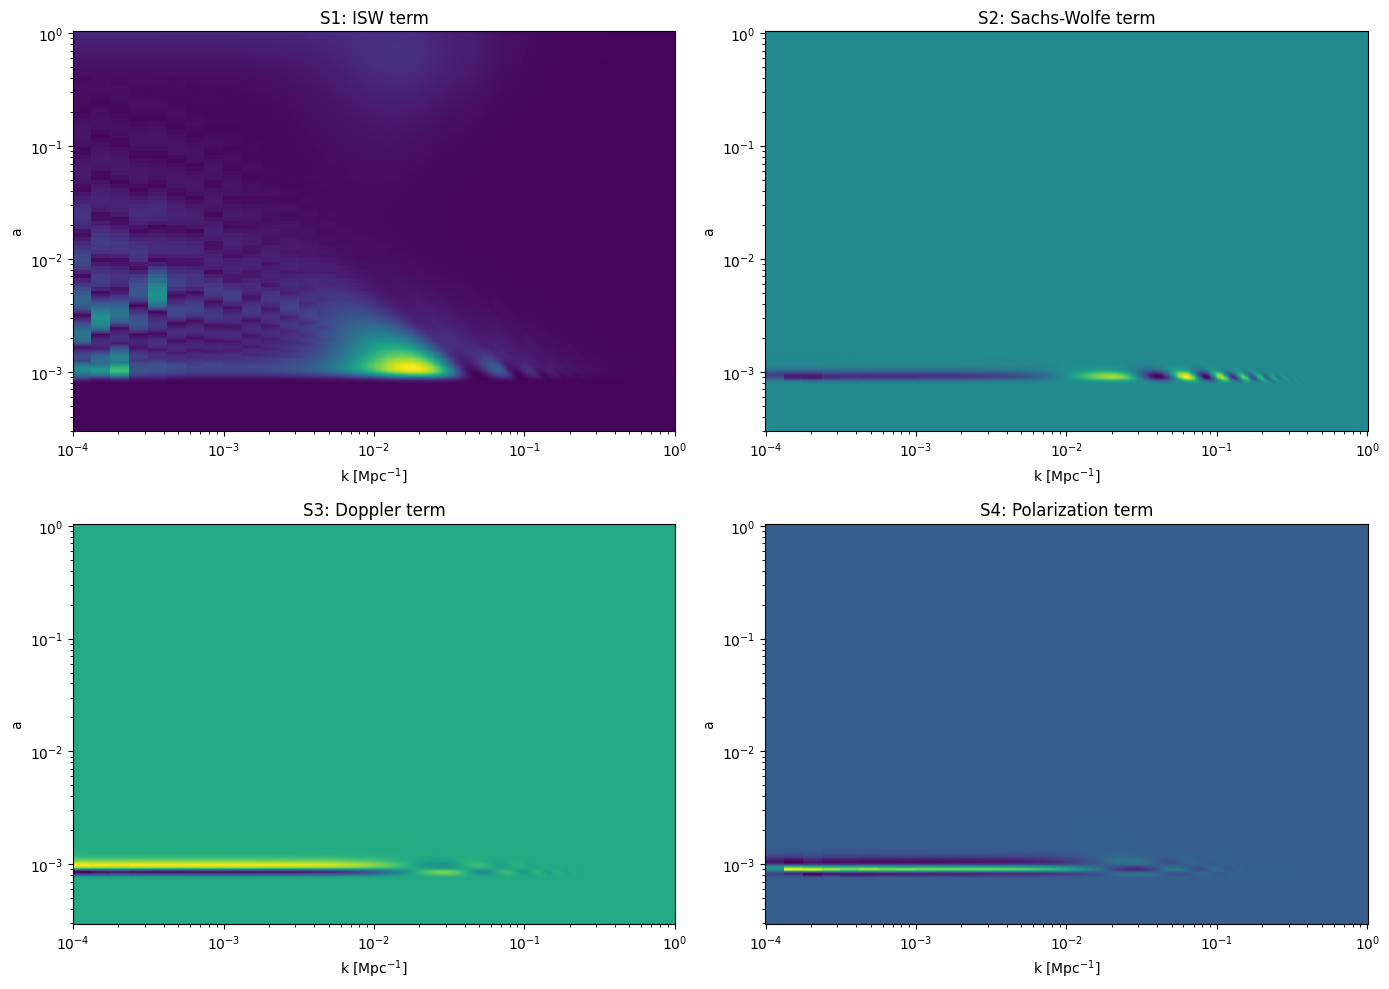

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.pcolormesh(kmodes, aexp_out, S1.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S1: ISW term')

ax = axes[0, 1]
ax.pcolormesh(kmodes, aexp_out, S2.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S2: Sachs-Wolfe term')

ax = axes[1, 0]
ax.pcolormesh(kmodes, aexp_out, S3.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S3: Doppler term')

ax = axes[1, 1]
ax.pcolormesh(kmodes, aexp_out, S4.T, shading='auto')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel('a')
ax.set_title('S4: Polarization term')

plt.tight_layout()
plt.show()

## Line-of-sight integration

Integrate the source function with spherical Bessel functions to get multipole moments:
$$\Theta_\ell(k) = \int_0^{\tau_0} S(k,\tau) \, j_\ell(k(\tau_0-\tau)) \, d\tau$$

In [12]:
# Line-of-sight integration parameters
ellmax = 2500
nk_fine = 4096
chunk_size = 1024
k_chunk_size = 1024

# Get conformal time today
tau0 = param['tau_of_a_spline'].evaluate(1.0)

print(f"Computing multipole moments Θ_ℓ(k) up to ℓ={ellmax}...")
theta_ell, kmodes_fine = compute_theta_ell(
    ellmax=ellmax,
    kmodes=kmodes,
    tau=tau,
    S=S,
    tau0=tau0,
    nk_fine=nk_fine,
    chunk_size=chunk_size,
    k_chunk_size=k_chunk_size
)
print(f"Multipole moments computed. Shape: {theta_ell.shape}")

Computing multipole moments Θ_ℓ(k) up to ℓ=2500...
Multipole moments computed. Shape: (4096, 2501)


In [13]:
print(f"Computing C_ℓ angular power spectrum...")
Cell = compute_Cell(
    theta_ell=theta_ell,
    kmodes_fine=kmodes_fine,
    n_s=param['n_s'],
    k_p=param['k_p']
)
print(f"C_ℓ computed. Shape: {Cell.shape}")

Computing C_ℓ angular power spectrum...
C_ℓ computed. Shape: (2501,)


## Compare with CAMB

In [14]:
import camb

H0 = param['H0']
h = H0 / 100
ombh2 = param['Omegab'] * h**2
omch2 = (param['Omegam'] - param['Omegab']) * h**2
As = param['A_s']
ns = param['n_s']
mnu = param['mnu']

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=0.0, tau=0.0, mnu=mnu)
pars.InitPower.set_params(As=As, ns=ns)

results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='K')

ell_camb = jnp.arange(2, powers['unlensed_total'].shape[0])
D_ell = powers['unlensed_total'][2:, 0]

## Plot comparison

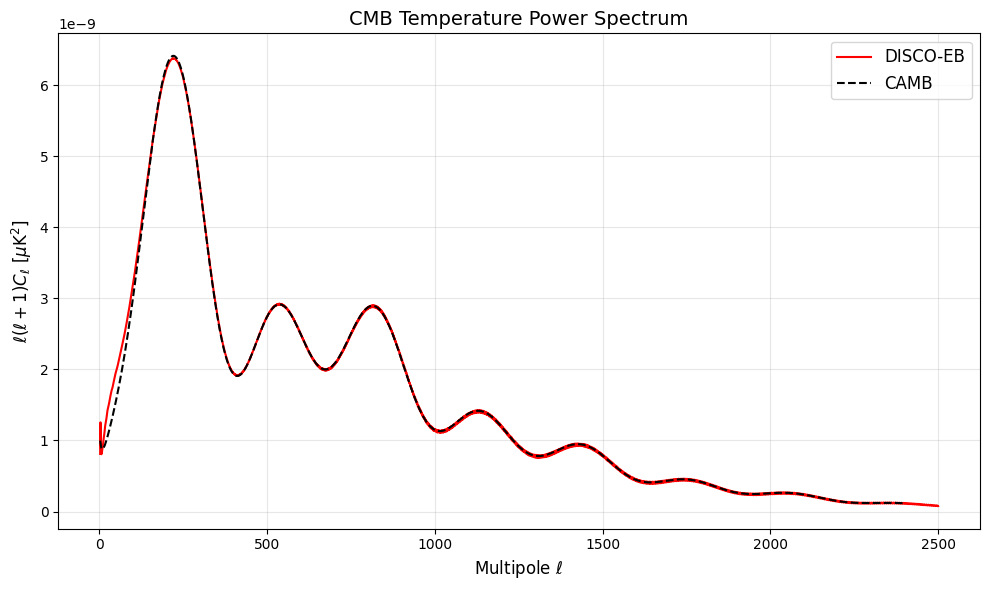

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ell = jnp.arange(ellmax + 1)
D_ell_discoeb = ell[2:] * (ell[2:] + 1) * Cell[2:] * param['A_s'] * 2 * param['Tcmb']**2

ax.plot(ell[2:], D_ell_discoeb, 'r-', label='DISCO-EB', linewidth=1.5)
ax.plot(ell_camb, D_ell, 'k--', label='CAMB', linewidth=1.5)

ax.legend(fontsize=12)
ax.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell$ [$\mu$K$^2$]', fontsize=12)
ax.set_title('CMB Temperature Power Spectrum', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()